# Foveation on a Cat Image

We apply eccentricity-dependent blur on a natural cat image resized to $256\times256$.


## Load and resize cat image

We use `matlab/fourier-curves/cat.png` and create a fixed-size 256x256 RGB array.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter
from IPython import get_ipython
import ipywidgets as widgets

ip=get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib","inline")

OUT = Path('.')
img = mpimg.imread('../../matlab/fourier-curves/cat.png').astype(float)
if img.max() > 1: img /= 255.0
img = img[..., :3] if img.ndim==3 else np.stack([img,img,img], axis=2)
h0,w0,_ = img.shape
ii = np.linspace(0, h0-1, 256).astype(int)
jj = np.linspace(0, w0-1, 256).astype(int)
img = img[np.ix_(ii, jj)]
H,W,_ = img.shape
Y,X = np.mgrid[0:H,0:W]
print('shape', img.shape)


shape (256, 256, 3)


## Foveation model

We blend several Gaussian blur levels according to radial distance from fixation point.


In [2]:
levels = [0.0, 1.2, 2.8, 5.5, 10.0]
BLUR = []
for s in levels:
    if s == 0:
        BLUR.append(img.copy())
    else:
        BLUR.append(gaussian_filter(img, sigma=(s,s,0)))
BLUR = np.stack(BLUR, axis=0)
lev = np.array(levels)

def foveate(cx, cy, radius):
    d = np.sqrt((X-cx)**2 + (Y-cy)**2)
    sigma_map = 10.0*np.clip(d/(radius+1e-9), 0, 1)
    idx = np.searchsorted(lev, sigma_map, side='right') - 1
    idx = np.clip(idx, 0, len(lev)-2)
    lo = lev[idx]
    hi = lev[idx+1]
    t = np.where(hi>lo, (sigma_map-lo)/(hi-lo), 0.0)[...,None]
    a = BLUR[idx, Y, X]
    b = BLUR[idx+1, Y, X]
    return np.clip((1-t)*a + t*b, 0, 1)


## Static panel at multiple fixation points/radii


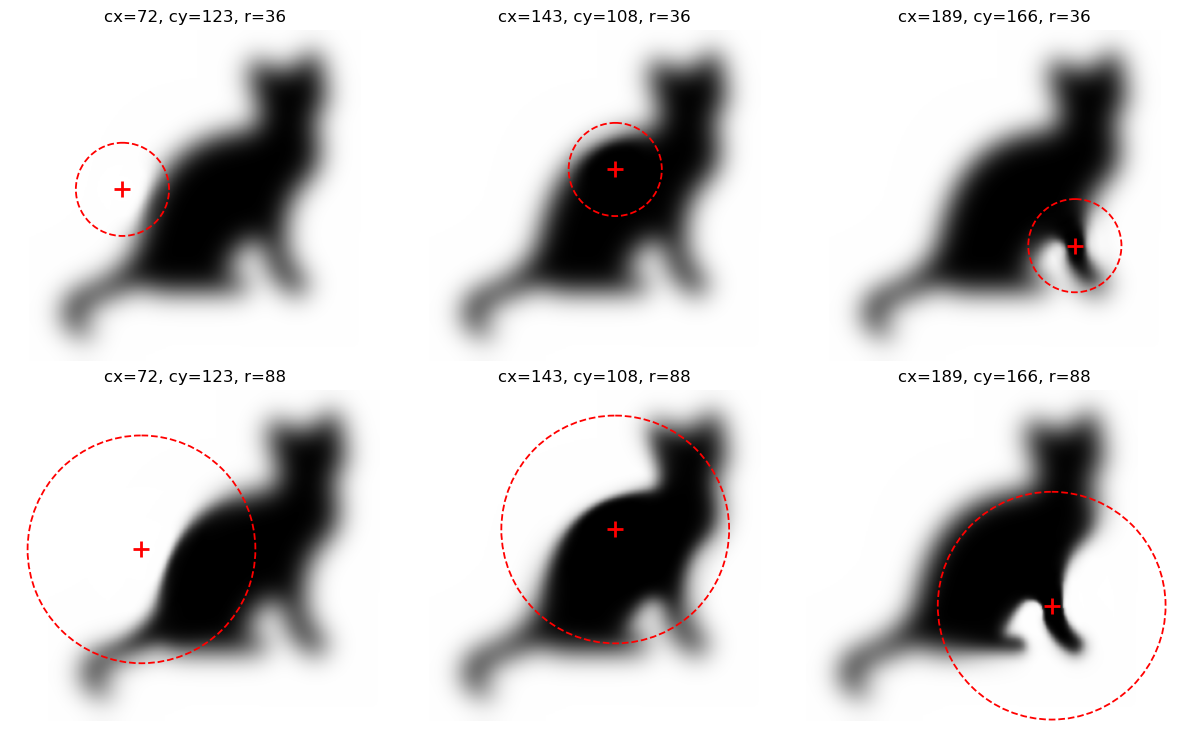

In [3]:
fix = [(0.28*W,0.48*H),(0.56*W,0.42*H),(0.74*W,0.65*H)]
rads = [36, 88]
fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.2), constrained_layout=True)
for r,rad in enumerate(rads):
    for c,(cx,cy) in enumerate(fix):
        F = foveate(cx, cy, rad)
        ax = axes[r,c]
        ax.imshow(F)
        ax.plot(cx, cy, 'r+', ms=12, mew=2)
        circ = plt.Circle((cx,cy), rad, edgecolor='red', facecolor='none', linestyle='--', lw=1.3)
        ax.add_patch(circ)
        ax.set_title(f'cx={cx:.0f}, cy={cy:.0f}, r={rad}')
        ax.axis('off')
fig.savefig(OUT / 'snippet.png', bbox_inches='tight')
plt.show()


## Interactive fixation/radius explorer
